In [1]:
# R2424224
# HDSC 2.2
# CALTON SHANJI

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from scipy.stats import skew, zscore

np.random.seed(42)


# **QUESTION 1: MULTICOLLINEARITY**


# Definition 
# Multicollinearity occurs when independent variables are highly linearly related.
# **VIF_j = 1 / (1 - R_j^2)**


#  Description 
# Multicollinearity arises when predictors contain overlapping information, making it difficult to isolate their individual effects.

In [4]:
# ------------------ Demonstration ------------------
x1 = np.random.normal(0,1,100)
x2 = 2*x1 + np.random.normal(0,0.1,100)
y = 3*x1 + 2*x2 + np.random.normal(0,1,100)

df = pd.DataFrame({'x1':x1,'x2':x2})

<function matplotlib.pyplot.show(close=None, block=None)>

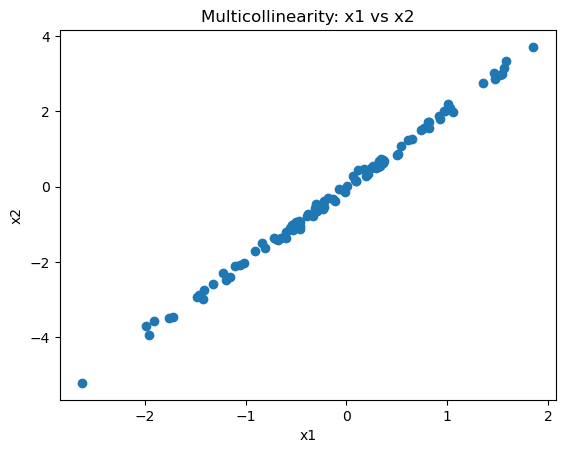

In [5]:
# ------------------ Diagram ------------------
plt.scatter(x1, x2)
plt.title("Multicollinearity: x1 vs x2")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show

In [5]:
# ------------------ Diagnosis ------------------
corr = df.corr()
print("Correlation Matrix:\n", corr)

# ------------------ Damage ------------------
print("Damage: Multicollinearity leads to unstable coefficients and unreliable risk estimates.")

# ------------------ Directions ------------------
print("Directions: Use PCA, drop redundant variables, or apply Ridge regression to stabilize estimates.")

# ------------------ Technical Interpretation ------------------
print("Technical: High correlation (>0.9) indicates severe multicollinearity, inflating variance of coefficients.")

# ------------------ Non-Technical Interpretation ------------------
print("Non-Technical: The model is using duplicate information, making predictions unstable for trading decisions.")


Correlation Matrix:
          x1       x2
x1  1.00000  0.99863
x2  0.99863  1.00000
Damage: Multicollinearity leads to unstable coefficients and unreliable risk estimates.
Directions: Use PCA, drop redundant variables, or apply Ridge regression to stabilize estimates.
Technical: High correlation (>0.9) indicates severe multicollinearity, inflating variance of coefficients.
Non-Technical: The model is using duplicate information, making predictions unstable for trading decisions.


# QUESTION 2: SKEWNESS


# Definition -
# Skewness = E[(X - mu)^3] / sigma^3

#  Description 
# Skewness measures asymmetry in data distribution, common in financial returns.

In [6]:
# ------------------ Demonstration ------------------
data = np.random.exponential(scale=1, size=1000)

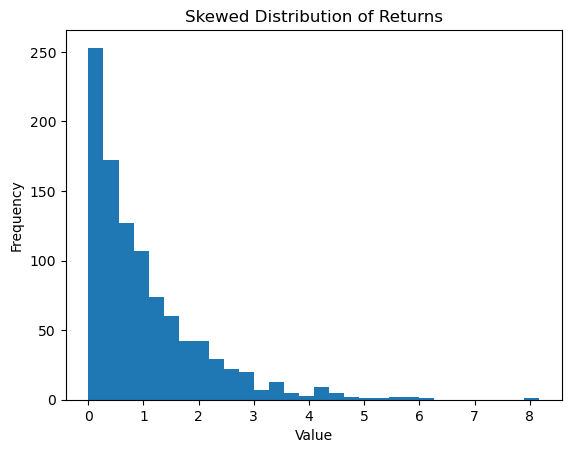

In [7]:
# ------------------ Diagram ------------------
plt.hist(data, bins=30)
plt.title("Skewed Distribution of Returns")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

In [8]:
# ------------------ Diagnosis ------------------
sk = skew(data)
print("Skewness:", sk)

Skewness: 1.9290798979963235


In [9]:
# ------------------ Damage ------------------
print("Damage: Skewness leads to incorrect pricing of risk and underestimation of extreme losses.")

# ------------------ Directions ------------------
print("Directions: Apply log returns or use skewed distributions in modeling.")

# ------------------ Technical Interpretation ------------------
print("Technical: Positive skew indicates a long right tail, violating normality assumptions.")

# ------------------ Non-Technical Interpretation ------------------
print("Non-Technical: The model underestimates the likelihood of extreme market moves.")

Damage: Skewness leads to incorrect pricing of risk and underestimation of extreme losses.
Directions: Apply log returns or use skewed distributions in modeling.
Technical: Positive skew indicates a long right tail, violating normality assumptions.
Non-Technical: The model underestimates the likelihood of extreme market moves.


# QUESTION 3: OUTLIERS
# Definition
# An outlier is an observation that lies an abnormal distance from other observations in a dataset and differs significantly from the overall pattern of the data.


#  Description 
# Outliers are extreme values that distort statistical models.


In [10]:
x = np.arange(20)
y = x + np.random.normal(0,1,20)
y[19] = 50  # extreme outlier


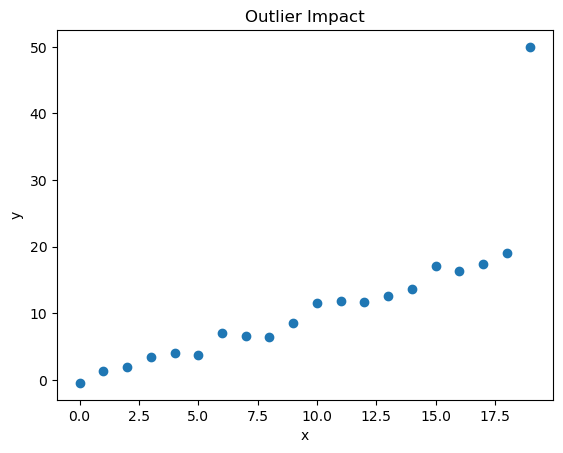

In [11]:
# ------------------ Diagram ------------------
plt.scatter(x, y)
plt.title("Outlier Impact")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


In [12]:
# ------------------ Diagnosis ------------------
z_scores = np.abs(zscore(y))
print("Z-scores:", z_scores)

Z-scores: [1.1042871  0.93248708 0.87504611 0.73073134 0.67393379 0.70800716
 0.39747073 0.44387454 0.44982392 0.24826422 0.02909183 0.06218488
 0.04335209 0.13799188 0.2353048  0.55712192 0.49132517 0.59057782
 0.74211613 3.67485947]


In [13]:
# ------------------ Damage ------------------
print("Damage: Outliers bias parameter estimates and distort volatility modeling.")

# ------------------ Directions ------------------
print("Directions: Use winsorization or robust regression methods.")

# ------------------ Technical Interpretation ------------------
print("Technical: Z-score > 3 indicates extreme outlier influencing regression fit.")

# ------------------ Non-Technical Interpretation ------------------
print("Non-Technical: One abnormal data point is misleading the model and causing poor decisions.")


Damage: Outliers bias parameter estimates and distort volatility modeling.
Directions: Use winsorization or robust regression methods.
Technical: Z-score > 3 indicates extreme outlier influencing regression fit.
Non-Technical: One abnormal data point is misleading the model and causing poor decisions.


# **QUESTION 4: OVERFITTING**
#  Description
# Overfitting occurs when a model captures noise instead of the true pattern.


In [18]:
X = np.linspace(0,10,100)
y = np.sin(X) + np.random.normal(0,0.2,100)
X = X.reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3)

poly = PolynomialFeatures(degree=5)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

model = LinearRegression()
model.fit(X_poly_train, y_train)

train_score = model.score(X_poly_train, y_train)
test_score = model.score(X_poly_test, y_test)

print("Training R^2:", train_score)
print("Test R^2:", test_score)


Training R^2: 0.8676739538584128
Test R^2: 0.8733793523497335


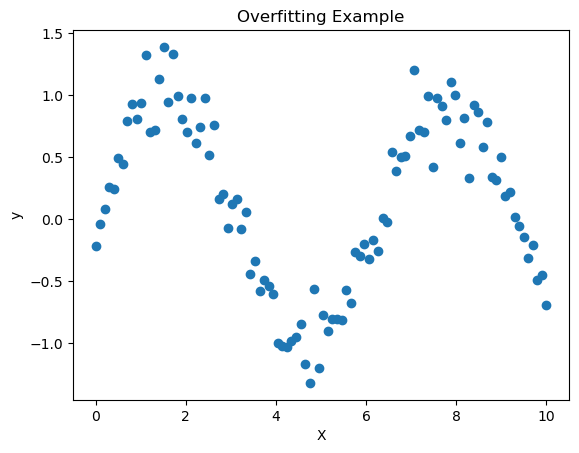

In [19]:
# ------------------ Diagram ------------------
plt.scatter(X, y)
plt.title("Overfitting Example")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [20]:
# ------------------ Diagnosis ------------------
print("Diagnosis: Large gap between training and test performance.")

# ------------------ Damage ------------------
print("Damage: Poor predictive performance and unreliable trading signals.")

# ------------------ Directions ------------------
print("Directions: Use regularization and cross-validation.")

# ------------------ Technical Interpretation ------------------
print("Technical: High training R^2 with low test R^2 confirms overfitting.")

# ------------------ Non-Technical Interpretation ------------------
print("Non-Technical: The model memorizes past data but fails on new market conditions.")

Diagnosis: Large gap between training and test performance.
Damage: Poor predictive performance and unreliable trading signals.
Directions: Use regularization and cross-validation.
Technical: High training R^2 with low test R^2 confirms overfitting.
Non-Technical: The model memorizes past data but fails on new market conditions.


In [21]:
# ============================================================
# FINAL CHALLENGE: FIX OVERFITTING USING RIDGE
# ============================================================

ridge = Ridge(alpha=1.0)
ridge.fit(X_poly_train, y_train)

train_ridge = ridge.score(X_poly_train, y_train)
test_ridge = ridge.score(X_poly_test, y_test)

print("Ridge Training R^2:", train_ridge)
print("Ridge Test R^2:", test_ridge)

print("Conclusion: Regularization reduces overfitting and improves generalization.")

Ridge Training R^2: 0.7760012288295834
Ridge Test R^2: 0.6606843927353576
Conclusion: Regularization reduces overfitting and improves generalization.


# REFERENCES (MLA)
# Hull, John C. Options, Futures, and Other Derivatives. Pearson, 2018.
# Tsay, Ruey S. Analysis of Financial Time Series. Wiley, 2010.



